# 02 - Preprocesamiento: Filtrado, Segmentación, Normalización

**Fase del Pipeline DSR: Preparación de Datos**

Este notebook demuestra el pipeline de preprocesamiento de ECG:
1. Filtrado paso banda Butterworth (0.5-40 Hz)
2. Detección QRS y localización del pico R
3. Segmentación de latidos (200 muestras = 90 antes + 110 después del pico R)
4. Normalización Z-score por latido

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.seeding import set_global_seed
from ecg_anomaly.data.loader import MITBIHLoader
from ecg_anomaly.preprocessing.filters import butterworth_bandpass
from ecg_anomaly.preprocessing.segmentation import segment_beats, normalize_beats
from ecg_anomaly.preprocessing.qrs_detection import pan_tompkins
from ecg_anomaly.preprocessing.pipeline import PreprocessingPipeline
from ecg_anomaly.visualization.signals import plot_raw_vs_filtered, plot_signal_with_peaks, plot_beat_overlay

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()
set_global_seed(config.random_seed)

## 1. Cargar un Registro de Muestra

In [14]:
loader = MITBIHLoader(config)
dataset = loader.load(config.dataset_path, records=["100"])
record = dataset.records[0]

print(f"Record {record.record_id}: {len(record.signal)} samples at {record.sampling_rate} Hz")
print(f"Duration: {len(record.signal) / record.sampling_rate:.1f} seconds")
print(f"Annotated beats: {len(record.r_peak_positions)}")

15:10:14 [ecg_anomaly.data.loader] INFO: Cargados 1 registros: 2273 latidos (2239 normal, 34 anomalo)


Record 100: 650000 samples at 360 Hz
Duration: 1805.6 seconds
Annotated beats: 2273


## 2. Filtro Paso Banda Butterworth: Crudo vs Filtrado

El filtro paso banda (0.5-40 Hz, Butterworth 4to orden) elimina:
- Deriva de línea base (< 0.5 Hz)
- Ruido de alta frecuencia y artefactos EMG (> 40 Hz)

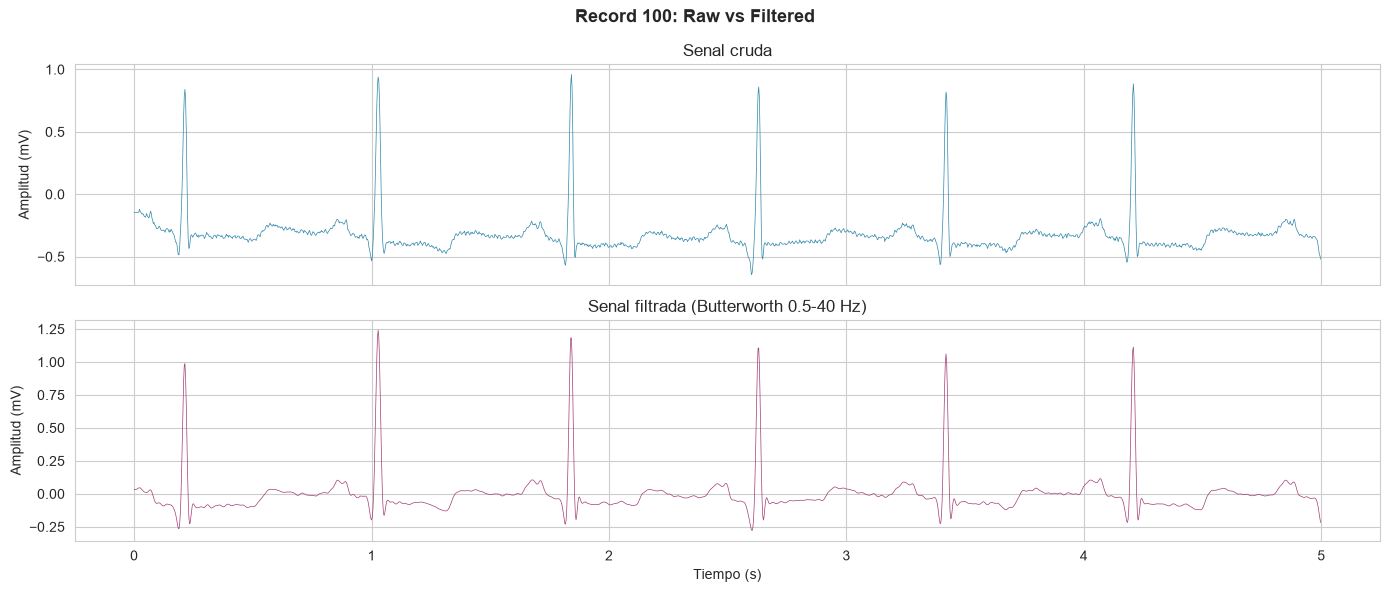

In [15]:
raw_signal = record.signal
filtered_signal = butterworth_bandpass(
    raw_signal,
    lowcut=config.filter_lowcut,
    highcut=config.filter_highcut,
    fs=config.sampling_rate,
    order=config.filter_order,
)

plot_raw_vs_filtered(
    raw_signal, filtered_signal,
    fs=config.sampling_rate,
    duration_seconds=5.0,
    title=f"Record {record.record_id}: Raw vs Filtered",
)

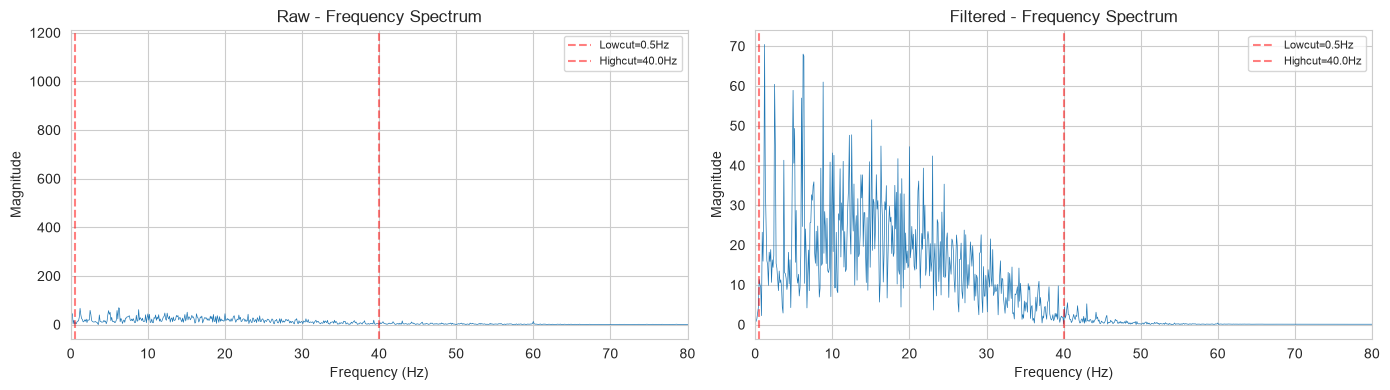

In [16]:
# Frequency domain comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, sig, title in [(axes[0], raw_signal, "Raw"), (axes[1], filtered_signal, "Filtered")]:
    fft_vals = np.abs(np.fft.rfft(sig[:config.sampling_rate * 10]))
    freqs = np.fft.rfftfreq(config.sampling_rate * 10, d=1.0/config.sampling_rate)
    ax.plot(freqs, fft_vals, linewidth=0.5)
    ax.set_xlim(0, 80)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"{title} - Frequency Spectrum")
    ax.axvline(config.filter_lowcut, color="r", linestyle="--", alpha=0.5, label=f"Lowcut={config.filter_lowcut}Hz")
    ax.axvline(config.filter_highcut, color="r", linestyle="--", alpha=0.5, label=f"Highcut={config.filter_highcut}Hz")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Detección QRS y Localización del Pico R

MIT-BIH proporciona posiciones de picos R anotadas por expertos como verdad de campo.
El pipeline utiliza estas anotaciones en lugar de redetectar QRS.

A continuación también mostramos el detector Pan-Tompkins como referencia.

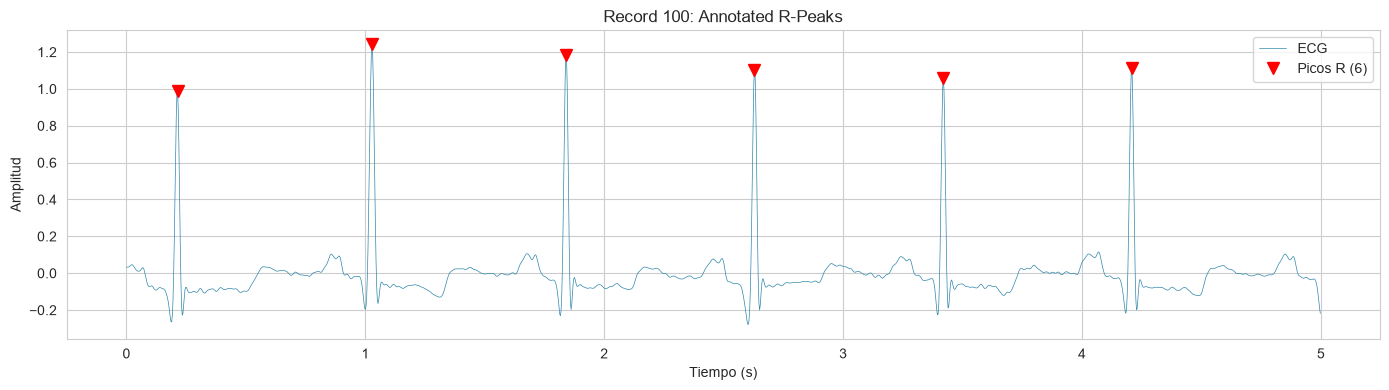

In [17]:
# Annotated R-peaks (ground truth)
plot_signal_with_peaks(
    filtered_signal,
    record.r_peak_positions,
    fs=config.sampling_rate,
    duration_seconds=5.0,
    title=f"Record {record.record_id}: Annotated R-Peaks",
)

Annotated R-peaks: 2273
Pan-Tompkins detected: 2273


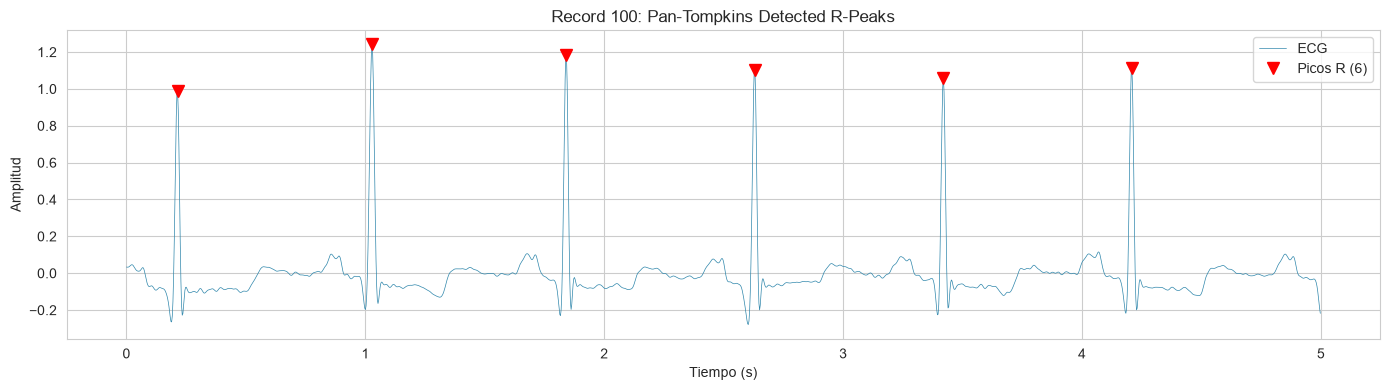

In [18]:
# Pan-Tompkins detection for comparison
detected_peaks = pan_tompkins(filtered_signal, fs=config.sampling_rate)
print(f"Annotated R-peaks: {len(record.r_peak_positions)}")
print(f"Pan-Tompkins detected: {len(detected_peaks)}")

plot_signal_with_peaks(
    filtered_signal,
    detected_peaks,
    fs=config.sampling_rate,
    duration_seconds=5.0,
    title=f"Record {record.record_id}: Pan-Tompkins Detected R-Peaks",
)

## 4. Segmentación de Latidos

Cada latido se extrae como una ventana de 200 muestras alrededor del pico R:
- **90 muestras antes** del pico R (~250 ms a 360 Hz)
- **110 muestras después** del pico R (~305 ms a 360 Hz)

Los latidos en los bordes de la señal donde la ventana se extendería más allá
de los límites de la grabación se descartan.

In [19]:
segments, valid_idx = segment_beats(
    filtered_signal,
    record.r_peak_positions,
    before=config.before_r_samples,
    after=config.after_r_samples,
)

print(f"Beat window: {config.before_r_samples} + {config.after_r_samples} = {config.beat_length} samples")
print(f"Input R-peaks: {len(record.r_peak_positions)}")
print(f"Valid segments extracted: {segments.shape[0]}")
print(f"Segment shape: {segments.shape}")

Beat window: 90 + 110 = 200 samples
Input R-peaks: 2273
Valid segments extracted: 2271
Segment shape: (2271, 200)


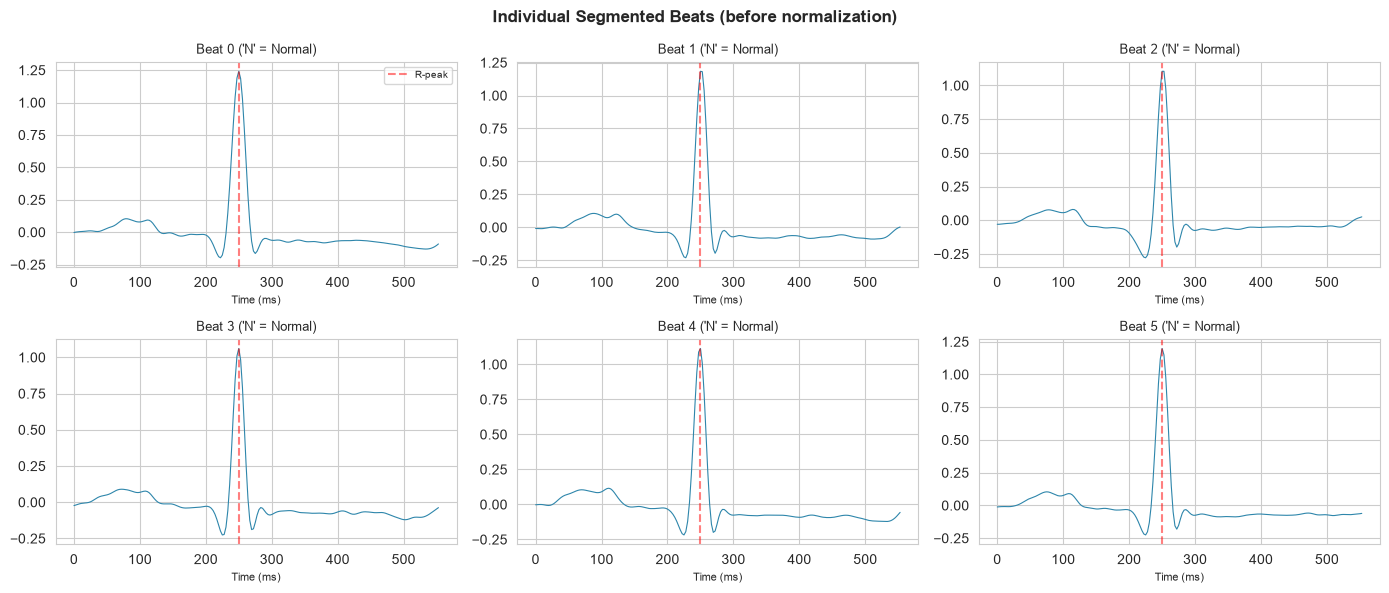

In [20]:
# Show individual segmented beats (before normalization)
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
t_ms = np.arange(config.beat_length) / config.sampling_rate * 1000

for i, ax in enumerate(axes.flat):
    ax.plot(t_ms, segments[i], color="#2E86AB", linewidth=0.8)
    ax.axvline(config.before_r_samples / config.sampling_rate * 1000, color="red",
               linestyle="--", alpha=0.5, label="R-peak")
    label = record.binary_labels[valid_idx[i]]
    symbol = record.symbols[valid_idx[i]]
    status = "Normal" if label == 0 else "Anomalous"
    ax.set_title(f"Beat {i} ('{symbol}' = {status})", fontsize=9)
    ax.set_xlabel("Time (ms)", fontsize=8)

axes[0, 0].legend(fontsize=7)
plt.suptitle("Individual Segmented Beats (before normalization)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Normalización Z-Score

Cada latido se normaliza independientemente a media cero y varianza unitaria.
Esto elimina diferencias de amplitud entre derivaciones y pacientes mientras
preserva la forma morfológica.

In [21]:
normalized = normalize_beats(segments)

print(f"Before normalization - mean: {segments[0].mean():.4f}, std: {segments[0].std():.4f}")
print(f"After normalization  - mean: {normalized[0].mean():.6f}, std: {normalized[0].std():.4f}")

Before normalization - mean: 0.0061, std: 0.2218
After normalization  - mean: 0.000000, std: 1.0000


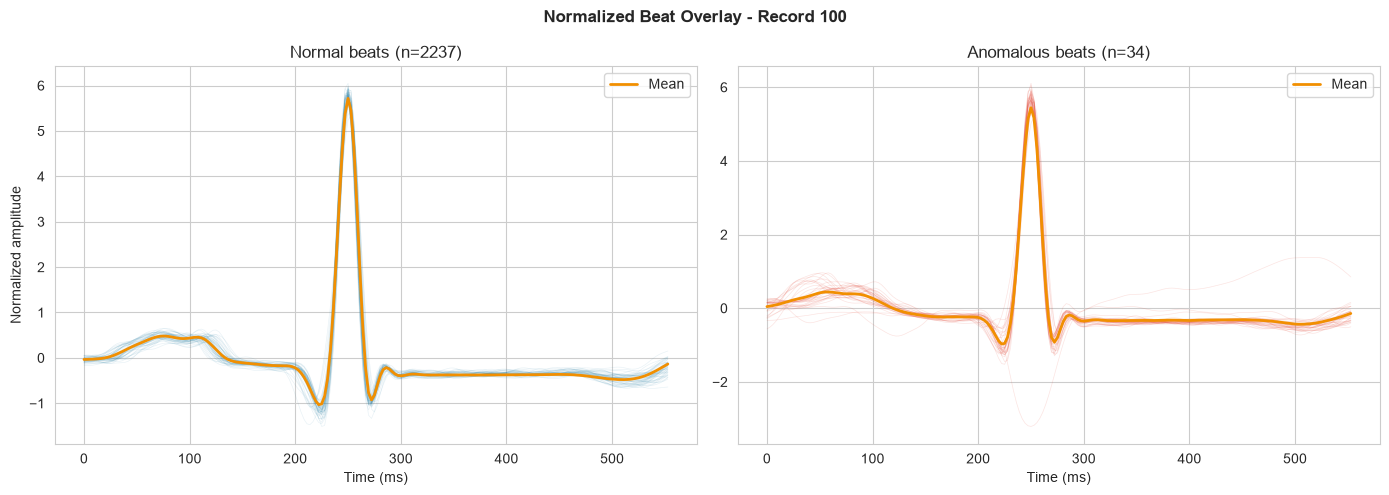

In [22]:
# Overlay normalized beats: normal vs anomalous
labels = record.binary_labels[valid_idx]
normal_mask = labels == 0
anomaly_mask = labels == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal beats overlay
for i in np.where(normal_mask)[0][:50]:
    axes[0].plot(t_ms, normalized[i], alpha=0.1, color="#2E86AB", linewidth=0.5)
axes[0].plot(t_ms, normalized[normal_mask].mean(axis=0), color="#F18F01", linewidth=2, label="Mean")
axes[0].set_title(f"Normal beats (n={int(normal_mask.sum())})")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Normalized amplitude")
axes[0].legend()

# Anomalous beats overlay
if anomaly_mask.sum() > 0:
    for i in np.where(anomaly_mask)[0][:50]:
        axes[1].plot(t_ms, normalized[i], alpha=0.15, color="#E74C3C", linewidth=0.5)
    axes[1].plot(t_ms, normalized[anomaly_mask].mean(axis=0), color="#F18F01", linewidth=2, label="Mean")
axes[1].set_title(f"Anomalous beats (n={int(anomaly_mask.sum())})")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.suptitle(f"Normalized Beat Overlay - Record {record.record_id}", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Ejecución Completa del Pipeline

`PreprocessingPipeline` ejecuta todos los pasos (filtrar -> segmentar -> normalizar)
en todo el dataset en una sola llamada.

In [23]:
# Load full dataset and run pipeline
full_dataset = loader.load(config.dataset_path)
pipeline = PreprocessingPipeline(config)
preprocessed = pipeline.run(full_dataset)

print(f"Preprocessed segments: {preprocessed.segments.shape}")
print(f"Labels: {preprocessed.labels.shape}")
print(f"Normal: {preprocessed.metadata['n_normal']:,}")
print(f"Anomalous: {preprocessed.metadata['n_anomalous']:,}")
print(f"Records processed: {preprocessed.metadata['n_records']}")

15:10:22 [ecg_anomaly.data.loader] INFO: Cargados 44 registros: 100733 latidos (90125 normal, 10608 anomalo)
15:10:24 [ecg_anomaly.preprocessing.pipeline] INFO: Preprocesamiento completo: 100705 latidos [100705, 200] (normal=90099, anomalo=10606)


Preprocessed segments: (100705, 200)
Labels: (100705,)
Normal: 90,099
Anomalous: 10,606
Records processed: 44


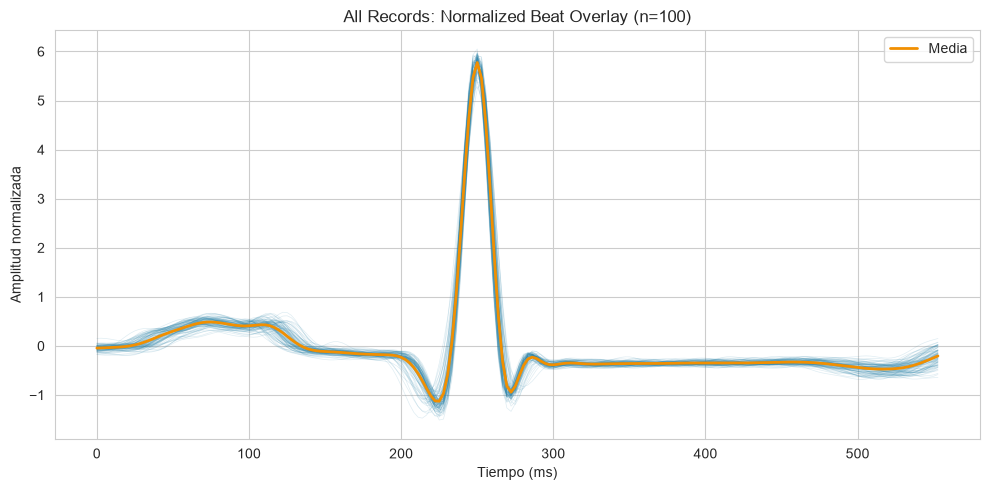

In [24]:
# Full dataset beat overlay
plot_beat_overlay(
    preprocessed.segments,
    n_beats=100,
    fs=config.sampling_rate,
    title="All Records: Normalized Beat Overlay",
)

## Resumen

El pipeline de preprocesamiento produce una matriz de forma `[N, 200]` donde cada
fila es un latido normalizado. Parámetros clave:
- Filtro paso banda: 0.5-40 Hz, Butterworth 4to orden
- Ventana de latido: 90 + 110 = 200 muestras (~555 ms a 360 Hz)
- Normalización: Z-score por latido

**Siguiente:** `03_feature_extraction.ipynb` -- reducción a componentes PCA o características manuales.